# **Experiment 2**

In [1]:
# Do not modify this code
!pip install -q utstd imbalanced-learn

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

In [3]:
import pandas as pd

pd.__version__

'2.2.2'

---
## Student Information

In [4]:
# <Student to fill this section>
student_name = "Ratnadeep Patra"
student_id = "26294153"

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

In [7]:
import adv_ml_at2 as at2
import cloudpickle
import matplotlib.pyplot as plt
import numpy as np
import optuna
import seaborn as sns

from adv_ml_at2.modeling.custom_models import make_smote_classifier
from mlweave.workflow.workflow import MLWorkflow
from mlweave.workflow.decorators.step import inference_step
from optuna.integration import OptunaSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, recall_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("max_colwidth", None)

optuna.logging.set_verbosity(optuna.logging.WARNING)


---
## A. Project Description

In [8]:
forecast_horizons_days = 7

business_use_case_description = f"""
Experiment 2 keeps the same goal of predicting Sydney's Weather Hazard Category exactly {forecast_horizons_days} days ahead. The output remains a four-class hazard category used to support outdoor operations, transport scheduling,
event planning and weather-risk communication. This experiment specifically tests whether correcting the severe class imbalance can make the model more useful for identifying High Risk and Extreme Risk weather.
"""

In [9]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [10]:
business_objectives = """
Experiment 1 produced stable overall scores but failed to predict any High Risk or Extreme Risk cases on the held-out test period. Experiment 2 therefore focuses on improving minority high-risk detection while retaining useful
four-class discrimination. Missed high-risk events remain the more important operational error, while false alerts are also monitored because excessive warnings would reduce trust in the model.
"""

In [11]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [12]:
stakeholders_expectations_explanations = f"""
Operational planners still require a {forecast_horizons_days}-day warning signal that distinguishes Low, Moderate, High and Extreme Risk conditions. The model should detect more genuinely hazardous days than Experiment 1 without
creating an impractical number of false high-risk alerts.
"""

In [13]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

> Hypothesis: Experiment 1 suggests that severe class imbalance limits the model's ability to learn High and Extreme Risk decision boundaries. Proportion-aware SMOTE will improve severity-weighted recall and High/Extreme Risk detection by increasing minority-class representation during training, while scaling the amount of oversampling according to how under-represented each class already is.

---
## C. Data Understanding

### C.1 Load Raw Data

In [14]:
hourly_weather_df = pd.read_csv(at2.dataset.RAW_DATA_DIR / "sydney_weather_hourly.csv", parse_dates=["time"])
daily_weather_df = pd.read_csv(at2.dataset.RAW_DATA_DIR / "sydney_weather_daily.csv", parse_dates=["time"])

aggregation_rules = {
    "temperature_2m": ["mean", "max", "min", "median"],
    "relative_humidity_2m": ["mean", "max", "min", "median"],
    "wind_speed_10m": ["mean", "max"],
    "wind_speed_100m": ["mean", "max"],
    "wind_gusts_10m": ["mean", "max"],
    "cloud_cover": ["mean", "max"],
    "cloud_cover_low": ["mean", "max"],
    "cloud_cover_mid": ["mean", "max"],
    "cloud_cover_high": ["mean", "max"],
    "precipitation": ["sum", "max"],
    "snowfall": ["sum"],
    "pressure_msl": ["mean", "max", "min"],
    "dew_point_2m": ["mean", "max", "min"],
    "vapour_pressure_deficit": ["mean", "max"],
    "soil_moisture_0_to_7cm": ["mean"],
    "apparent_temperature": ["mean", "max", "min"],
    "shortwave_radiation": ["mean", "max"],
    "sunshine_duration": ["sum"]
}

daily_features_df = at2.dataset.build_daily_weather_dataset(hourly_weather_df=hourly_weather_df, daily_weather_df=daily_weather_df, aggregation_rules=aggregation_rules)
print("Daily weather shape:", daily_features_df.shape)

Daily weather shape: (9497, 45)


In [15]:
global_data_insight = """
Experiment 2 reuses the same raw weather observations, target construction, selected features, engineered features, chronological split and standardisation from Experiment 1. The controlled change is proportion-aware SMOTE applied
only to the training partition, so validation and test observations retain their original class distributions.

A single sampling multiplier controls the maximum oversampling strength. The increase applied to each minority class is automatically reduced when that class is already close to the majority-class size, while severely rare classes
receive close to the full requested multiplier.
"""

In [16]:
# Do not modify this code
print_tile(size="h3", key="global_data_insight", value=global_data_insight)

### C.2 Define Target variable

In [17]:
target_name = f"whc_target_{forecast_horizons_days}d"
target_label_name = f"whc_label_target_{forecast_horizons_days}d"

whc_class_definitions = pd.DataFrame([
    {"WHI condition": "WHI < 25", "WHC class": 0, "WHC label": "Low Risk"},
    {"WHI condition": "25 <= WHI < 50", "WHC class": 1, "WHC label": "Moderate Risk"},
    {"WHI condition": "50 <= WHI < 75", "WHC class": 2, "WHC label": "High Risk"},
    {"WHI condition": "WHI >= 75", "WHC class": 3, "WHC label": "Extreme Risk"}
])
display(whc_class_definitions)

,WHI condition,WHC class,WHC label
0,WHI < 25,0,Low Risk
1,25 <= WHI < 50,1,Moderate Risk
2,50 <= WHI < 75,2,High Risk
3,WHI >= 75,3,Extreme Risk


In [18]:
target_definition_explanations = f"""
The target definition is unchanged from Experiment 1. WHC is predicted {forecast_horizons_days} days ahead using the same four ordered risk categories and the same leakage-safe lagged predictor space.
"""

In [19]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [20]:
daily_whi_df = at2.features.aggregate_daily_whi(hourly_weather_df)
hazard_columns = ["rain_hazard", "wind_hazard", "cloud_hazard", "snow_hazard", "temperature_hazard", "whi", "whc", "whc_label"]

weather_df = daily_features_df.merge(daily_whi_df[["time"] + hazard_columns], on="time", how="inner", validate="one_to_one")
weather_df = at2.features.create_whc_forecast_targets(weather_df, horizon=forecast_horizons_days)
weather_df = at2.features.lag_feature_space(weather_df, target_columns=[target_name, target_label_name], lag_days=1)
weather_df = weather_df.dropna(subset=[target_name]).reset_index(drop=True)
weather_df[target_name] = weather_df[target_name].astype("int64")
print(f"Final supervised rows: {len(weather_df):,}")

Final supervised rows: 9,489


### C.4 Explore Target variable

In [21]:
target_distribution = weather_df[target_name].value_counts().sort_index().rename("count").to_frame()
target_distribution["label"] = target_distribution.index.map(at2.features.WHC_LABELS)
target_distribution["proportion"] = target_distribution["count"] / target_distribution["count"].sum()
display(target_distribution[["label", "count", "proportion"]].round(4))

,label,count,proportion
whc_target_7d,,,
0,Low Risk,5239,0.5521
1,Moderate Risk,3965,0.4179
2,High Risk,274,0.0289
3,Extreme Risk,11,0.0012


In [22]:
target_distribution_explanations = """
The severe class imbalance identified in Experiment 1 remains unchanged. Low and Moderate Risk observations dominate the data, while High Risk is uncommon and Extreme Risk is extremely rare. This imbalance is the specific
modelling issue tested in Experiment 2.
"""

In [23]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

---
## D. Feature Selection

### D.1 Approach "Reuse Experiment 1 Selection"

In [24]:
feature_selection_1_insights = """
Experiment 2 reuses the final Experiment 1 feature selection unchanged. The Experiment 1 ablation study showed that reducing the engineered feature space did not improve performance, so no additional feature removal is introduced here.
"""

In [25]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

---
## E. Data Preparation

### E.1 Data Transformation "Reuse Experiment 1 Pipeline"

In [26]:
experiment_1_path = at2.config.MODELS_DIR / "weather_hazard" / "experiment_1" / "experiment_1.pkl"

if not experiment_1_path.exists():
    raise FileNotFoundError("Run Experiment 1 through the pipeline-saving section before running Experiment 2.")

with experiment_1_path.open("rb") as file:
    experiment_2_preprocessing = cloudpickle.load(file)

print("Reused preprocessing steps:", [name for name, step in experiment_2_preprocessing.steps if step != "passthrough"])

Reused preprocessing steps: ['retain_selected_features', 'add_log1p_precipitation', 'add_annual_cycle_features', 'add_multi_scale_whi_history', 'add_multi_scale_whi_memory', 'add_multi_scale_whi_rolling_stats', 'retain_complete_temporal_context', 'temporal_train_validation_test_split', 'standardise_model_matrix']


In [27]:
data_transformation_1_explanations = """
The fitted Experiment 1 preprocessing pipeline is reused directly. This preserves its selected variables, log precipitation transformation, annual cycle, WHI history, exponentially weighted memory, rolling statistics, temporal
context filtering, chronological split and training-fitted standardisation.
"""

In [28]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

---
## F. Feature Engineering

### F.1 New Feature "Reuse Experiment 1 Engineered Features"

In [29]:
feature_engineering_seasonality_explanations = """
No new predictors are introduced in Experiment 2. The complete engineered feature space from Experiment 1 is retained so the experiment isolates the effect of changing minority-class representation during model training.
"""

In [30]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_seasonality_explanations', value=feature_engineering_seasonality_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [31]:
X_train, X_val, X_test = experiment_2_preprocessing.fit_transform(weather_df)
y_train, y_val, y_test = experiment_2_preprocessing.multiplex_y_

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_val), len(X_test)],
    "proportion": np.array([len(X_train), len(X_val), len(X_test)]) / (len(X_train) + len(X_val) + len(X_test))
}, index=["train", "validation", "test"])

display(split_summary)
display(pd.concat({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "validation": y_val.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index()
}, axis=1).fillna(0).round(4))

,rows,proportion
train,8006,0.846300
validation,730,0.077167
test,724,0.076533


,train,validation,test
whc_target_7d,,,
0,0.5697,0.4836,0.4309
1,0.4039,0.4671,0.5180
2,0.0254,0.0466,0.0497
3,0.0010,0.0027,0.0014


In [32]:
data_splitting_explanations = """
The chronological train, validation and test partitions are produced by the reused Experiment 1 pipeline, keeping Experiment 2 directly comparable with the original classification baseline.
"""

In [33]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "Training-Fitted Standardisation"

In [34]:
data_transformation_3_explanations = """
The Experiment 1 preprocessing pipeline is reused unchanged. SMOTE is applied only after preprocessing and only during model fitting. Validation and test observations are never resampled, preserving a realistic evaluation of
performance on the original class distribution.
"""

In [35]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

In [36]:
data_final_path = at2.config.PROCESSED_DATA_DIR / "weather_hazard" / "experiment_2"
data_final_path.mkdir(parents=True, exist_ok=True)

In [37]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(f'{data_final_path}/X_train.csv', index=False)
  y_train.to_csv(f'{data_final_path}/y_train.csv', index=False)

  X_val.to_csv(f'{data_final_path}/X_val.csv', index=False)
  y_val.to_csv(f'{data_final_path}/y_val.csv', index=False)

  X_test.to_csv(f'{data_final_path}/X_test.csv', index=False)
  y_test.to_csv(f'{data_final_path}/y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

In [38]:
class_ids = sorted(at2.features.WHC_LABELS)
high_group_ids = class_ids[2:]
severity_weights = np.array([1, 1, 2, 3])

def severity_weighted_recall(y_true, y_pred):
    class_recalls = recall_score(y_true, y_pred, labels=class_ids, average=None, zero_division=0)
    return np.average(class_recalls, weights=severity_weights)

primary_metric = "severity_weighted_recall"
classification_scorer = make_scorer(severity_weighted_recall)

In [39]:
performance_metrics_explanations = f"""
Experiment 2 reuses the same {primary_metric} introduced in Experiment 1 so model comparison remains consistent. Recall is calculated independently for all four WHC classes and combined using severity weights of
{severity_weights.tolist()} for Low, Moderate, High and Extreme Risk respectively. This gives greater importance to detecting the more hazardous classes while retaining recall across the full four-class target.
"""

In [40]:
# Do not modify this code
print_tile(size="h3", key="performance_metrics_explanations", value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

In [41]:
algorithm_selection_explanations = """
Experiment 2 retains Elastic-Net Logistic Regression but introduces proportion-aware SMOTE to address the severe class imbalance identified in Experiment 1. Class weighting changes the contribution of minority errors to the loss,
but preliminary testing did not improve identification of actual High/Extreme Risk days. SMOTE instead increases the number of minority training observations available to the classifier.

A fixed SMOTE target such as balancing every class to the majority could be too aggressive, particularly for the very small Extreme Risk class. The custom wrapper therefore uses a single sampling multiplier together with each
class's representation relative to the majority. Very rare classes receive close to the full multiplier, while classes already close to the majority receive a smaller increase. All target counts remain capped at the majority count.
"""

In [42]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

In [43]:
C = 0.1
l1_ratio = 0.9
intercept = True
k_neighbors = 3
sampling_multipliers = [1.0, 2.0, 3.0, 5.0]

In [44]:
hyperparameters_selection_explanations = f"""
The initial comparison keeps Logistic Regression fixed at C={C}, l1_ratio={l1_ratio}, fit_intercept={intercept} and k_neighbors={k_neighbors}, while testing sampling multipliers {sampling_multipliers}. A multiplier of 1 applies no
oversampling. For larger values, each minority class receives an increase based on both the requested multiplier and its rarity relative to the majority class.

Optuna then tunes the sampling multiplier, SMOTE neighbourhood size, C and l1_ratio jointly. The l1_ratio search remains concentrated near strong L1 regularisation because Experiment 1 found its strongest validation performance
when the complete engineered feature set was retained with substantial L1 regularisation.
"""

In [45]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [46]:
def test_model(sampling_multiplier, C, l1_ratio, k_neighbors):
    model = make_smote_classifier(
        LogisticRegression(penalty="elasticnet", solver="saga", C=C, l1_ratio=l1_ratio, fit_intercept=True, max_iter=5000, random_state=42),
        sampling_multiplier=sampling_multiplier,
        k_neighbors=k_neighbors,
        random_state=42
    )
    model.fit(X_train, y_train)

    result = {
        "sampling_multiplier": sampling_multiplier,
        "k_neighbors": k_neighbors,
        "training_rows": sum(model.class_counts_after_.values()),
        f"train_{primary_metric}": severity_weighted_recall(y_train, model.predict(X_train)),
        f"val_{primary_metric}": severity_weighted_recall(y_val, model.predict(X_val))
    }
    return pd.DataFrame([result]), model

def test_different_multiplier_model(C, l1_ratio, k_neighbors):
    sampling_multipliers = [1, 5, 10, 25, 50, 100]
    results = []
    models = []
    for sampling_multiplier in sampling_multipliers:
        result, model = test_model(
            sampling_multiplier,
            C=C,
            l1_ratio=l1_ratio,
            k_neighbors=k_neighbors
        )
        results.append(result)
        models.append(model)
    return pd.concat(results, ignore_index=True), models

In [47]:
metric1, models1 = test_different_multiplier_model(C=0.1, l1_ratio=1.0, k_neighbors=3)
display(metric1)

,sampling_multiplier,k_neighbors,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,1,3,8006,0.167315,0.158887
1,5,3,10141,0.171285,0.151038
2,10,3,11151,0.176245,0.148162
3,25,3,13883,0.260492,0.230258
4,50,3,14083,0.473412,0.227815
5,100,3,14482,0.517549,0.222916


In [48]:
metric2, models2 = test_different_multiplier_model(C=0.1, l1_ratio=0.0, k_neighbors=3)
display(metric2)

,sampling_multiplier,k_neighbors,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,1,3,8006,0.166191,0.157439
1,5,3,10141,0.171262,0.155227
2,10,3,11151,0.178499,0.150299
3,25,3,13883,0.313816,0.228710
4,50,3,14083,0.474377,0.226687
5,100,3,14482,0.573887,0.221802


In [49]:
metric3, models3 = test_different_multiplier_model(C=0.1, l1_ratio=1.0, k_neighbors=5)
display(metric3)

,sampling_multiplier,k_neighbors,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,1,5,8006,0.167315,0.158887
1,5,5,10141,0.170885,0.153075
2,10,5,11151,0.183685,0.166992
3,25,5,13883,0.260137,0.238356
4,50,5,14083,0.364597,0.235928
5,100,5,14482,0.514542,0.231448


In [50]:
metric4, models4 = test_different_multiplier_model(C=0.1, l1_ratio=1.0, k_neighbors=7)
display(metric4)

,sampling_multiplier,k_neighbors,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,1,7,8006,0.167315,0.158887
1,5,7,10141,0.170984,0.151861
2,10,7,11151,0.179490,0.173777
3,25,7,13883,0.264867,0.241917
4,50,7,14083,0.368922,0.239894
5,100,7,14482,0.467016,0.237061


In [51]:
metric5, model5 = test_model(sampling_multiplier=25, C=0.2, l1_ratio=1.0, k_neighbors=7)
display(metric5)

,sampling_multiplier,k_neighbors,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,25,7,13883,0.36883,0.242379


In [52]:
metric6, model6 = test_model(sampling_multiplier=25, C=0.05, l1_ratio=1.0, k_neighbors=7)
display(metric6)

,sampling_multiplier,k_neighbors,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,25,7,13883,0.263301,0.252763


In [53]:
metric7, model7 = test_model(sampling_multiplier=25, C=0.01, l1_ratio=1.0, k_neighbors=7)
display(metric7)

,sampling_multiplier,k_neighbors,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,25,7,13883,0.255323,0.224659


In [54]:
metric8, model8 = test_model(sampling_multiplier=25, C=0.05, l1_ratio=0.8, k_neighbors=7)
display(metric8)

,sampling_multiplier,k_neighbors,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,25,7,13883,0.263283,0.250683


In [55]:
optuna_space = {
    "sampling_multiplier": optuna.distributions.FloatDistribution(20.0, 40.0, log=True),
    "k_neighbors": optuna.distributions.IntDistribution(6, 8),
    "estimator__C": optuna.distributions.FloatDistribution(1e-2, 1e-1, log=True),
    "estimator__l1_ratio": optuna.distributions.FloatDistribution(0.7, 1.0)
}

@inference_step
def evaluate_classification(context):
    predictions = context.model.predict(context.X_test)
    return {primary_metric: severity_weighted_recall(context.y_test, predictions)}

search = OptunaSearchCV(
    estimator=make_smote_classifier(
        LogisticRegression(penalty="elasticnet", solver="saga", fit_intercept=True, max_iter=5000, random_state=42),
        random_state=42
    ),
    param_distributions=optuna_space,
    n_trials=50,
    scoring=classification_scorer,
    refit=True,
    return_train_score=True,
    random_state=42
)

optuna_workflow = MLWorkflow(
    preprocessing=experiment_2_preprocessing,
    model_search=search,
    inference=evaluate_classification()
)

In [56]:
optuna_output = optuna_workflow.run(weather_df, track=False)

final_model = optuna_workflow.model_search_.best_estimator_
best_index = optuna_workflow.model_search_.best_index_

best_model_results = pd.DataFrame([{
    **optuna_workflow.best_params_,
    f"train_{primary_metric}": severity_weighted_recall(y_train, final_model.predict(X_train)),
    f"val_{primary_metric}": severity_weighted_recall(y_val, final_model.predict(X_val)),
}])

display(best_model_results.round(4))

,sampling_multiplier,k_neighbors,estimator__C,estimator__l1_ratio,train_severity_weighted_recall,val_severity_weighted_recall
0,31.9482,8,0.0415,0.8427,0.2514,0.2874


### J.4 Model Technical Performance

In [57]:
partitions = {
    "Training": (X_train, y_train),
    "Validation": (X_val, y_val),
    "Test": (X_test, y_test)
}

technical_performance = pd.DataFrame([
    {
        "partition": partition_name,
        primary_metric: severity_weighted_recall(y, final_model.predict(X))
    }
    for partition_name, (X, y) in partitions.items()
]).set_index("partition")

display(technical_performance.round(4))

,severity_weighted_recall
partition,
Training,0.2514
Validation,0.2874
Test,0.1806


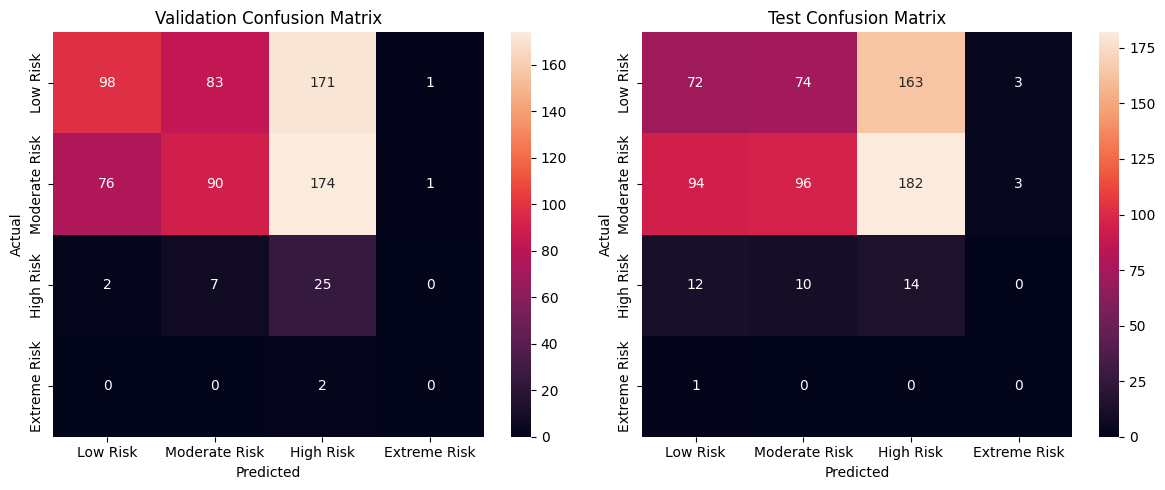

In [58]:
validation_predictions = final_model.predict(X_val)
test_predictions = final_model.predict(X_test)
class_names = [at2.features.WHC_LABELS[class_id] for class_id in class_ids]

figure, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, predictions, actual, title in [
    (axes[0], validation_predictions, y_val, "Validation Confusion Matrix"),
    (axes[1], test_predictions, y_test, "Test Confusion Matrix")
]:
    matrix = confusion_matrix(actual, predictions, labels=class_ids)
    sns.heatmap(matrix, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set(title=title, xlabel="Predicted", ylabel="Actual")

figure.tight_layout()

In [59]:
model_performance_explanations = f"""
The proportion-aware SMOTE model achieves a {primary_metric} of
{technical_performance.loc["Training", primary_metric]:.4f} on training,
{technical_performance.loc["Validation", primary_metric]:.4f} on validation and
{technical_performance.loc["Test", primary_metric]:.4f} on test.

Validation performance is higher than training, indicating that the model is not simply overfitting the resampled training data. However, the reduction to
{technical_performance.loc["Test", primary_metric]:.4f} on the held-out test period shows that minority-class detection does not generalise equally well across time.

The confusion matrices show that SMOTE changes the model behaviour substantially by enabling it to predict High Risk observations. It correctly identifies
25 High Risk observations on validation and 14 on test. However, many Low and Moderate Risk observations are also predicted as High Risk, indicating a trade-off
between improved hazardous-weather sensitivity and increased false alerts. Extreme Risk remains the most difficult class, with no Extreme Risk observations
correctly classified in either validation or test.

Overall, SMOTE improves the model's ability to recognise the minority High Risk class, but performance remains unstable for the rarest risk levels and the
increase in High Risk predictions introduces additional false positives.
"""

In [60]:
# Do not modify this code
print_tile(size="h3", key="model_performance_explanations", value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

In [61]:
high_group_ids = class_ids[2:]
business_rows = []

for partition, y, predictions in [
    ("Validation", y_val, validation_predictions),
    ("Test", y_test, test_predictions)
]:
    actual_high_risk = np.isin(y, high_group_ids)
    predicted_high_risk = np.isin(predictions, high_group_ids)

    caught_high_risk = (actual_high_risk & predicted_high_risk).sum()
    missed_high_risk = (actual_high_risk & ~predicted_high_risk).sum()
    false_alerts = (~actual_high_risk & predicted_high_risk).sum()

    business_rows.append({
        "partition": partition,
        "actual_high_risk_events": actual_high_risk.sum(),
        "predicted_high_risk_alerts": predicted_high_risk.sum(),
        "caught_high_risk_events": caught_high_risk,
        "missed_high_risk_events": missed_high_risk,
        "false_high_risk_alerts": false_alerts,
        "high_risk_recall": caught_high_risk / actual_high_risk.sum(),
        "high_risk_alert_precision": caught_high_risk / predicted_high_risk.sum() if predicted_high_risk.sum() else np.nan
    })

business_impact = pd.DataFrame(business_rows).set_index("partition")
display(business_impact.round(4))

,actual_high_risk_events,predicted_high_risk_alerts,caught_high_risk_events,missed_high_risk_events,false_high_risk_alerts,high_risk_recall,high_risk_alert_precision
partition,,,,,,,
Validation,36,374,27,9,347,0.7500,0.0722
Test,37,365,14,23,351,0.3784,0.0384


In [62]:
test_business = business_impact.loc["Test"]
test_precision = test_business["high_risk_alert_precision"]
test_precision_text = "undefined because no alerts were produced" if pd.isna(test_precision) else f"{test_precision:.2%}"

business_impacts_explanations = f"""
On the held-out test period, the proportion-aware SMOTE model correctly identifies
{int(test_business["caught_high_risk_events"])} of {int(test_business["actual_high_risk_events"])} actual High or Extreme Risk events,
resulting in a high-risk recall of {test_business["high_risk_recall"]:.2%}.

The model produces {int(test_business["predicted_high_risk_alerts"])} High/Extreme Risk alerts, of which
{int(test_business["false_high_risk_alerts"])} are false alerts. This results in a high-risk alert precision of {test_precision_text}.

From a business perspective, SMOTE improves the model's ability to identify hazardous-weather conditions, but the increase in sensitivity also introduces false
alerts. The model therefore provides better warning coverage for High and Extreme Risk events, while the trade-off between missed hazardous events and unnecessary
alerts remains important when assessing operational usefulness.
"""

In [63]:
# Do not modify this code
print_tile(size="h3", key="business_impacts_explanations", value=business_impacts_explanations)

### J.6 Save Reusable Model

In [64]:
artifact_dir = at2.config.MODELS_DIR / "weather_hazard" / "experiment_2"
artifact_dir.mkdir(parents=True, exist_ok=True)
model_path = artifact_dir / "experiment_2.pkl"

with model_path.open("wb") as file:
    cloudpickle.dump(final_model, file)

print(f"Saved Experiment 2 model to: {model_path}")

Saved Experiment 2 model to: /Users/ratnadeeppatra/adv_ml/36120-26SP-AT2-26294153-experiments/models/weather_hazard/experiment_2/experiment_2.pkl


## H. Project Outcomes

In [65]:

experiment_outcome = "Hypothesis Confirmed"

In [66]:
# Do not modify this code
print_tile(size="h2", key="experiment_outcomes_explanations", value=experiment_outcome)

In [67]:
test_business = business_impact.loc["Test"]

experiment_results_explanations = f"""
{experiment_outcome}. The proportion-aware SMOTE model achieves a held-out test {primary_metric} of
{technical_performance.loc["Test", primary_metric]:.4f} and correctly identifies
{int(test_business["caught_high_risk_events"])} of {int(test_business["actual_high_risk_events"])} actual High or Extreme Risk events,
resulting in a high-risk recall of {test_business["high_risk_recall"]:.2%}.

The model produces {int(test_business["predicted_high_risk_alerts"])} High/Extreme Risk alerts and
{int(test_business["false_high_risk_alerts"])} false high-risk alerts. This shows that increasing minority-class representation through SMOTE enables the model
to identify hazardous-weather observations that were not being captured adequately in Experiment 1.

The hypothesis is therefore confirmed. The results support the view that insufficient minority representation was limiting the classifier's ability to learn
High and Extreme Risk decision boundaries. However, substantial confusion between the risk classes remains, suggesting that the linear Logistic Regression
decision boundary may now be a limiting factor.

Experiment 3 therefore retains the same feature representation and SMOTE strategy while comparing two non-linear tree ensembles. Random Forest tests whether
bagging many independently fitted decision trees can better capture non-linear weather relationships, while XGBoost tests whether sequentially correcting
previous prediction errors provides additional benefit. Their validation performance and high-risk detection will be compared to determine which approach
better addresses the remaining classification errors.
"""

In [68]:
# Do not modify this code
print_tile(size="h2", key="experiment_results_explanations", value=experiment_results_explanations)